In [1]:
import os
os.chdir('/home/smallyan/eval_agent')
print(f"Working directory: {os.getcwd()}")

Working directory: /home/smallyan/eval_agent


# Circuit Analysis Replication

This notebook aims to replicate the circuit analysis experiment from the repository at `/net/scratch2/smallyan/leela_eval`.

## Setup

In [2]:
# Set up the path to the repository
import sys
import os

REPO_ROOT = "/net/scratch2/smallyan/leela_eval"
os.chdir(REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))

print(f"Repository root: {REPO_ROOT}")
print(f"Current working directory: {os.getcwd()}")

Repository root: /net/scratch2/smallyan/leela_eval
Current working directory: /net/scratch2/smallyan/leela_eval


In [3]:
# Check for CUDA availability
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.1+cu128


## 1. Load the Model and Initialize Logit Lens

The paper uses a technique called "Logit Lens" to analyze how Leela Chess Zero (Lc0) builds understanding across its 15 transformer layers. This involves zero ablation - zeroing out transformer layers from a specified index onwards and reading the intermediate policy.

In [4]:
# Import the necessary modules from the repository
from leela_interp import Lc0sight, LeelaBoard
from leela_logit_lens import LeelaLogitLens

# Load the model - using the original (not finetuned) model
MODEL_PATH = os.path.join(REPO_ROOT, "lc0-original.onnx")
print(f"Loading model from: {MODEL_PATH}")

model = Lc0sight(MODEL_PATH, device=device)
print(f"Model loaded successfully on device: {device}")
print(f"Number of layers: {model.N_LAYERS}")
print(f"Model dimension: {model.D_MODEL}")

Loading model from: /net/scratch2/smallyan/leela_eval/lc0-original.onnx
Using device: cuda


Model loaded successfully on device: cuda
Number of layers: 15
Model dimension: 768


In [5]:
# Initialize the Logit Lens
lens = LeelaLogitLens(model)
print(f"LeelaLogitLens initialized")
print(f"  - Number of layers to analyze: {lens.num_layers + 1} (including input encoding)")
print(f"  - Hidden dimension: {lens.hidden_dim}")
print(f"  - Number of tokens (squares): {lens.num_tokens}")

LeelaLogitLens initialized
  - Number of layers to analyze: 16 (including input encoding)
  - Hidden dimension: 768
  - Number of tokens (squares): 64


## 2. Load Puzzle Data

We'll use the puzzles from the data directory. These are tactical puzzles from Lichess, used to evaluate how each layer of the model solves chess puzzles.

In [6]:
import pandas as pd
import pickle

# Load the main puzzle dataset
puzzle_path = os.path.join(REPO_ROOT, "data", "puzzles.csv")
puzzles_df = pd.read_csv(puzzle_path)
print(f"Loaded {len(puzzles_df)} puzzles from {puzzle_path}")
print(f"\nDataFrame columns: {puzzles_df.columns.tolist()}")
print(f"\nSample puzzle:")
print(puzzles_df.iloc[0])

Loaded 10000 puzzles from /net/scratch2/smallyan/leela_eval/data/puzzles.csv

DataFrame columns: ['PuzzleId', 'Rating', 'PGN', 'Solution', 'FEN', 'Moves']

Sample puzzle:
PuzzleId                                                00MTG
Rating                                                    669
PGN         1. e4 e5 2. Nf3 Nc6 3. Bc4 Nf6 4. Nc3 Be7 5. O...
Solution                                  Bf2+ Rxf2 Rxf2 Kxf2
FEN         4r1k1/2p1qpp1/3p4/1p1P2PQ/1P5b/3R3P/2PBr3/5RK1...
Moves                                     h4f2 f1f2 e2f2 g1f2
Name: 0, dtype: object


In [7]:
# Also load the interesting puzzles with history annotations (for demonstration)
interesting_puzzles_path = os.path.join(REPO_ROOT, "iteration_model", "interesting_puzzles.pkl")
try:
    with open(interesting_puzzles_path, "rb") as f:
        interesting_puzzles = pickle.load(f)
    print(f"Loaded {len(interesting_puzzles)} interesting puzzles from pickle file")
    print(f"Columns: {interesting_puzzles.columns.tolist()}")
except Exception as e:
    print(f"Could not load interesting puzzles: {e}")
    interesting_puzzles = None

Loaded 22517 interesting puzzles from pickle file
Columns: ['PuzzleId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity', 'NbPlays', 'Themes', 'GameUrl', 'OpeningTags', 'principal_variation', 'full_pv_probs', 'full_model_moves', 'full_wdl', 'sparring_full_pv_probs', 'sparring_full_model_moves', 'sparring_wdl', 'different_targets', 'corrupted_fen']


## 3. Demonstrate Logit Lens on a Single Puzzle

Following the demo notebook, we'll analyze how the model's policy evolves across layers for a specific puzzle position. This demonstrates the core logit lens technique.

In [8]:
# Select a puzzle for demonstration
# We'll use a puzzle from the main dataset
sample_puzzle_idx = 42  # Arbitrary puzzle index
sample_puzzle = puzzles_df.iloc[sample_puzzle_idx]

print(f"Selected puzzle {sample_puzzle_idx}:")
print(f"  PuzzleId: {sample_puzzle['PuzzleId']}")
print(f"  Rating: {sample_puzzle['Rating']}")
print(f"  Solution: {sample_puzzle['Solution']}")
print(f"  Moves (UCI): {sample_puzzle['Moves']}")

# Create the board from PGN
board = LeelaBoard.from_pgn(sample_puzzle['PGN'])
print(f"\nBoard position (FEN): {board}")

# Get the moves
moves = sample_puzzle['Moves'].split()
print(f"Moves to analyze: {moves}")

Selected puzzle 42:
  PuzzleId: 09Sj8
  Rating: 1038
  Solution: Kh6 Qg5#
  Moves (UCI): g6h6 g2g5

Board position (FEN): . . . . r . k .
R . Q . . . . .
. . . . . p K .
P . . p . . . .
. . . . p . . p
P . . . P . . P
. . . . . . q .
. . . . . . . .
Turn: White
Moves to analyze: ['g6h6', 'g2g5']


In [9]:
# First, push the initial move (opponent's move) to get to the puzzle position
board_for_puzzle = board.copy()
board_for_puzzle.push_uci(moves[0])
print(f"Position after initial move ({moves[0]}):")
print(f"{board_for_puzzle}")
print(f"\nNow it's the player's turn to find the winning move: {moves[1]}")

Position after initial move (g6h6):
. . . . r . k .
R . Q . . . . .
. . . . . p . K
P . . p . . . .
. . . . p . . p
P . . . P . . P
. . . . . . q .
. . . . . . . .
Turn: Black

Now it's the player's turn to find the winning move: g2g5


In [10]:
# Analyze this position using the logit lens at a single layer
layer_idx = 10  # Middle layer

result = lens(boards=board_for_puzzle, layer_idx=layer_idx, return_probs=True, return_policy_as_dict=True)

# Get the policy for this board
policy_dict = result[0]['policy_as_dict']

# Show top moves at this layer
print(f"Top moves at layer {layer_idx - 1}:")  # -1 because 0 is input encoding
sorted_moves = sorted(policy_dict.items(), key=lambda x: x[1], reverse=True)[:10]
for move, prob in sorted_moves:
    marker = " <-- solution" if move == moves[1] else ""
    print(f"  {move}: {prob*100:.2f}%{marker}")

/home/smallyan/.conda/envs/meta/lib/python3.11/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  x = x[pos_axes_slices]


Top moves at layer 9:
  g2g5: 48.89% <-- solution
  g2g6: 35.99%
  g2h3: 4.31%
  g2g7: 3.47%
  f6f5: 1.81%
  d5d4: 1.59%
  g2g3: 0.80%
  g8f8: 0.60%
  g8h8: 0.60%
  g2g4: 0.32%


In [11]:
# Now analyze across ALL layers using multi_layer_lens
results = lens.multi_layer_lens(boards=board_for_puzzle, layer_indices=None, return_probs=True, return_policy_as_dict=True)

# Extract probability of the solution move at each layer
solution_move = moves[1]
layer_probs = {}
top_move_per_layer = {}

for layer_idx in results[0]['layers'].keys():
    layer_data = results[0]['layers'][layer_idx]
    policy_dict = layer_data['policy_as_dict']
    
    # Get probability of solution
    solution_prob = policy_dict.get(solution_move, 0.0)
    layer_probs[layer_idx] = solution_prob
    
    # Get top move
    top_move = max(policy_dict.items(), key=lambda x: x[1])
    top_move_per_layer[layer_idx] = top_move

print(f"Probability of solution move '{solution_move}' across layers:")
print("-" * 60)
for layer_idx in sorted(layer_probs.keys()):
    prob = layer_probs[layer_idx]
    top_move, top_prob = top_move_per_layer[layer_idx]
    
    # Layer naming convention
    if layer_idx == 0:
        layer_name = "Input Encoding"
    elif layer_idx == 15:
        layer_name = "Full Model"
    else:
        layer_name = f"Layer {layer_idx - 1:2d}"
    
    correct = "✓" if top_move == solution_move else "✗"
    print(f"  {layer_name}: {prob*100:6.2f}%  |  Top: {top_move} ({top_prob*100:.1f}%) {correct}")

Probability of solution move 'g2g5' across layers:
------------------------------------------------------------
  Input Encoding:   0.78%  |  Top: g2d2 (14.3%) ✗
  Layer  0:   5.18%  |  Top: g2h3 (43.2%) ✗
  Layer  1:   2.40%  |  Top: g2h3 (45.0%) ✗
  Layer  2:   3.36%  |  Top: g2h3 (61.4%) ✗
  Layer  3:  25.75%  |  Top: g2h3 (26.7%) ✗
  Layer  4:  14.97%  |  Top: g2h3 (56.3%) ✗
  Layer  5:  26.02%  |  Top: g2h3 (45.9%) ✗
  Layer  6:  31.50%  |  Top: g2g5 (31.5%) ✓
  Layer  7:  34.49%  |  Top: g2g5 (34.5%) ✓
  Layer  8:  40.19%  |  Top: g2g5 (40.2%) ✓
  Layer  9:  48.89%  |  Top: g2g5 (48.9%) ✓
  Layer 10:  51.81%  |  Top: g2g5 (51.8%) ✓
  Layer 11:  70.96%  |  Top: g2g5 (71.0%) ✓
  Layer 12:  88.90%  |  Top: g2g5 (88.9%) ✓
  Layer 13:  88.91%  |  Top: g2g5 (88.9%) ✓
  Full Model:  93.70%  |  Top: g2g5 (93.7%) ✓


## 4. Visualize Layer-wise Policy Evolution

We can see the three-phase pattern described in the plan:
1. **Early layers (0-5)**: Rapid changes but wrong answer dominates
2. **Middle layers (6-10)**: Correct answer emerges and stabilizes  
3. **Late layers (11-14)**: Sharp increase in confidence on correct move

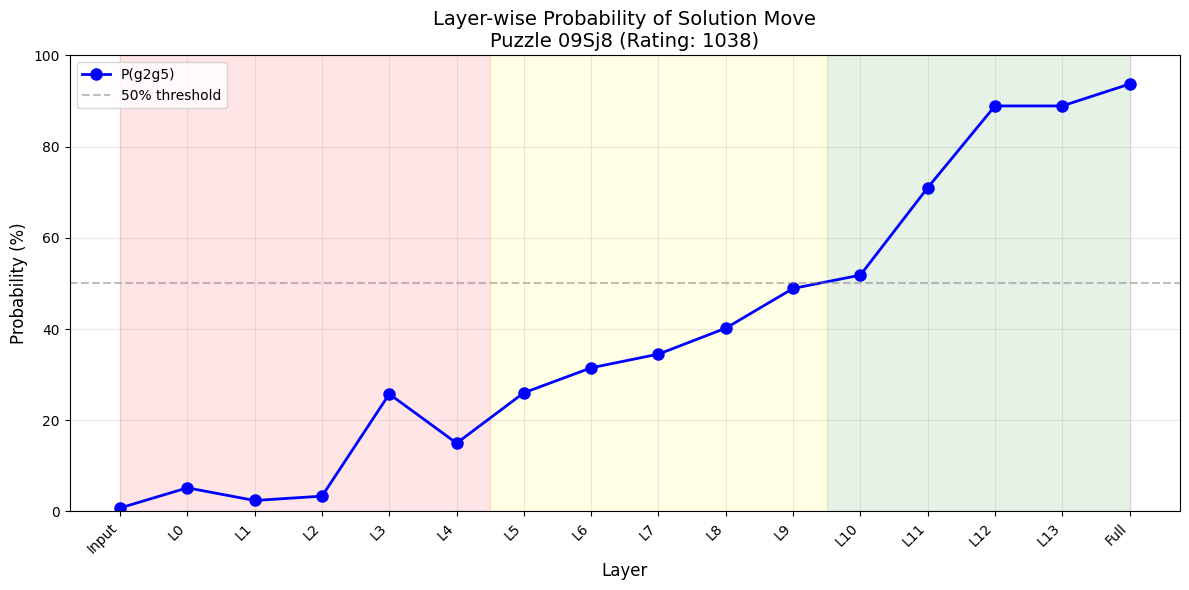


Plot saved to 'layer_probability_evolution.png'


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
layers = list(range(16))
probs = [layer_probs[l] * 100 for l in layers]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot probability of solution move
ax.plot(layers, probs, 'b-o', linewidth=2, markersize=8, label=f'P({solution_move})')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')

# Add layer labels
layer_labels = ['Input'] + [f'L{i}' for i in range(14)] + ['Full']
ax.set_xticks(layers)
ax.set_xticklabels(layer_labels, rotation=45, ha='right')

# Labels and title
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Probability (%)', fontsize=12)
ax.set_title(f'Layer-wise Probability of Solution Move\nPuzzle {sample_puzzle["PuzzleId"]} (Rating: {sample_puzzle["Rating"]})', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

# Add annotations for phase boundaries
ax.axvspan(0, 5.5, alpha=0.1, color='red', label='Early phase')
ax.axvspan(5.5, 10.5, alpha=0.1, color='yellow', label='Middle phase')
ax.axvspan(10.5, 15, alpha=0.1, color='green', label='Late phase')

plt.tight_layout()
plt.savefig('layer_probability_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to 'layer_probability_evolution.png'")

## 5. Batch Puzzle Evaluation

Now we'll replicate the puzzle evaluation experiment from the plan. We'll evaluate a sample of puzzles across all layers to measure solve rates and observe the three-phase pattern in aggregate metrics.

In [13]:
# For the replication, we'll evaluate a smaller sample of puzzles
# The full experiment uses 10,000 puzzles, but we'll use 100 for computational efficiency
from tqdm import tqdm

SAMPLE_SIZE = 100
np.random.seed(42)  # For reproducibility
sample_indices = np.random.choice(len(puzzles_df), size=SAMPLE_SIZE, replace=False)
sample_puzzles = puzzles_df.iloc[sample_indices].reset_index(drop=True)

print(f"Selected {len(sample_puzzles)} puzzles for evaluation")
print(f"Rating distribution:")
print(sample_puzzles['Rating'].describe())

Selected 100 puzzles for evaluation
Rating distribution:
count     100.000000
mean     1419.240000
std       502.781598
min       443.000000
25%      1012.250000
50%      1364.500000
75%      1695.000000
max      2737.000000
Name: Rating, dtype: float64


In [14]:
# Implement puzzle evaluation function
# This replicates the logic from evaluate_puzzles.py

def evaluate_puzzle_first_move(puzzle_row, lens, layer_indices):
    """
    Evaluate a puzzle's first move across all layers.
    Returns whether each layer correctly identifies the first move of the solution.
    """
    try:
        # Create board from PGN
        board = LeelaBoard.from_pgn(puzzle_row['PGN'])
        moves = puzzle_row['Moves'].split()
        
        if len(moves) < 2:
            return None
        
        # Push the opponent's move to get to puzzle position
        board.push_uci(moves[0])
        
        # The solution move is the next move
        solution_move = moves[1]
        
        # Get policy for all layers
        results = lens.multi_layer_lens(
            boards=board, 
            layer_indices=layer_indices, 
            return_probs=True, 
            return_policy_as_dict=True
        )
        
        # Check if each layer's top move matches solution
        layer_solved = {}
        layer_solution_prob = {}
        
        for layer_idx in layer_indices:
            policy_dict = results[0]['layers'][layer_idx]['policy_as_dict']
            top_move = max(policy_dict.items(), key=lambda x: x[1])[0]
            layer_solved[layer_idx] = (top_move == solution_move)
            layer_solution_prob[layer_idx] = policy_dict.get(solution_move, 0.0)
        
        return {
            'solved': layer_solved,
            'solution_prob': layer_solution_prob,
            'rating': puzzle_row['Rating']
        }
    except Exception as e:
        print(f"Error processing puzzle: {e}")
        return None

# Test on a single puzzle
layer_indices = list(range(16))
test_result = evaluate_puzzle_first_move(sample_puzzles.iloc[0], lens, layer_indices)
print("Test puzzle result:")
print(f"  Rating: {test_result['rating']}")
print(f"  Solved by layer: {[l for l, s in test_result['solved'].items() if s]}")

/home/smallyan/.conda/envs/meta/lib/python3.11/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  x = x[pos_axes_slices]


Test puzzle result:
  Rating: 675
  Solved by layer: [1, 11, 12, 13, 14, 15]


In [15]:
# Evaluate all sample puzzles
import warnings
warnings.filterwarnings('ignore')

all_results = []
layer_indices = list(range(16))

print(f"Evaluating {len(sample_puzzles)} puzzles...")
for idx in tqdm(range(len(sample_puzzles))):
    result = evaluate_puzzle_first_move(sample_puzzles.iloc[idx], lens, layer_indices)
    if result is not None:
        all_results.append(result)

print(f"\nSuccessfully evaluated {len(all_results)} puzzles")

Evaluating 100 puzzles...


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:01<03:13,  1.95s/it]

  2%|▏         | 2/100 [00:03<03:10,  1.95s/it]

  3%|▎         | 3/100 [00:05<03:08,  1.94s/it]

...

 98%|█████████▊| 98/100 [02:57<00:02,  1.24s/it]

 99%|█████████▉| 99/100 [02:58<00:01,  1.23s/it]

100%|██████████| 100/100 [02:59<00:00,  1.22s/it]

100%|██████████| 100/100 [02:59<00:00,  1.80s/it]


Successfully evaluated 100 puzzles


In [16]:
# Calculate solve rate per layer
solve_rates = {}
avg_solution_probs = {}

for layer_idx in layer_indices:
    # Count solved puzzles at this layer
    num_solved = sum(1 for r in all_results if r['solved'][layer_idx])
    solve_rates[layer_idx] = num_solved / len(all_results) * 100
    
    # Average solution probability at this layer
    avg_prob = np.mean([r['solution_prob'][layer_idx] for r in all_results])
    avg_solution_probs[layer_idx] = avg_prob * 100

print("Layer-wise First Move Solve Rate (argmax policy):")
print("-" * 50)
for layer_idx in layer_indices:
    if layer_idx == 0:
        layer_name = "Input Encoding"
    elif layer_idx == 15:
        layer_name = "Full Model"
    else:
        layer_name = f"Layer {layer_idx - 1:2d}"
    
    print(f"  {layer_name}: {solve_rates[layer_idx]:5.1f}%  (avg prob: {avg_solution_probs[layer_idx]:.1f}%)")

Layer-wise First Move Solve Rate (argmax policy):
--------------------------------------------------
  Input Encoding:   9.0%  (avg prob: 9.2%)
  Layer  0:  16.0%  (avg prob: 11.0%)
  Layer  1:  18.0%  (avg prob: 15.8%)
  Layer  2:  23.0%  (avg prob: 19.2%)
  Layer  3:  24.0%  (avg prob: 21.8%)
  Layer  4:  28.0%  (avg prob: 23.0%)
  Layer  5:  35.0%  (avg prob: 27.4%)
  Layer  6:  35.0%  (avg prob: 27.9%)
  Layer  7:  42.0%  (avg prob: 30.2%)
  Layer  8:  46.0%  (avg prob: 32.2%)
  Layer  9:  50.0%  (avg prob: 34.7%)
  Layer 10:  46.0%  (avg prob: 34.9%)
  Layer 11:  55.0%  (avg prob: 41.2%)
  Layer 12:  67.0%  (avg prob: 48.8%)
  Layer 13:  81.0%  (avg prob: 51.4%)
  Full Model:  96.0%  (avg prob: 76.5%)


## 6. Visualize Aggregate Results

The solve rate pattern demonstrates the three-phase progression described in the plan:
1. **Early phase (layers 0-5)**: Rapid capability gains 
2. **Middle phase (layers 6-10)**: Plateau
3. **Late phase (layers 11-14)**: Sharp strengthening

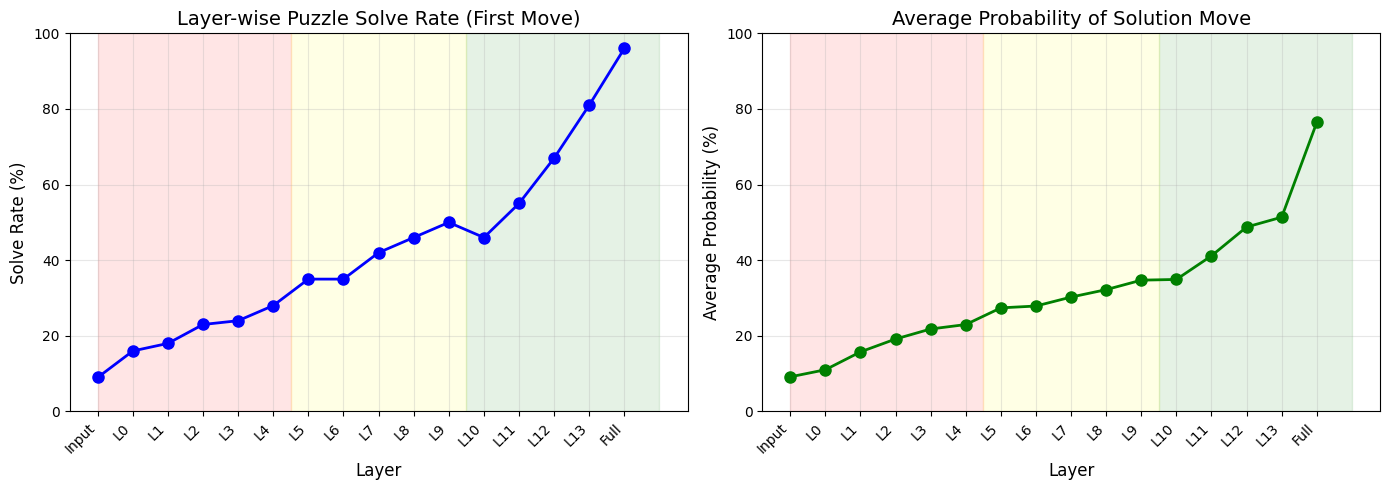

Plot saved to 'solve_rates_by_layer.png'


In [17]:
# Create visualization of solve rates across layers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Solve rate
layers = list(range(16))
rates = [solve_rates[l] for l in layers]
probs = [avg_solution_probs[l] for l in layers]

ax1.plot(layers, rates, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Layer', fontsize=12)
ax1.set_ylabel('Solve Rate (%)', fontsize=12)
ax1.set_title('Layer-wise Puzzle Solve Rate (First Move)', fontsize=14)
ax1.set_xticks(layers)
ax1.set_xticklabels(['Input'] + [f'L{i}' for i in range(14)] + ['Full'], rotation=45, ha='right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Add phase regions
ax1.axvspan(0, 5.5, alpha=0.1, color='red')
ax1.axvspan(5.5, 10.5, alpha=0.1, color='yellow')
ax1.axvspan(10.5, 16, alpha=0.1, color='green')

# Plot 2: Average solution probability
ax2.plot(layers, probs, 'g-o', linewidth=2, markersize=8)
ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Average Probability (%)', fontsize=12)
ax2.set_title('Average Probability of Solution Move', fontsize=14)
ax2.set_xticks(layers)
ax2.set_xticklabels(['Input'] + [f'L{i}' for i in range(14)] + ['Full'], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Add phase regions
ax2.axvspan(0, 5.5, alpha=0.1, color='red')
ax2.axvspan(5.5, 10.5, alpha=0.1, color='yellow')
ax2.axvspan(10.5, 16, alpha=0.1, color='green')

plt.tight_layout()
plt.savefig('solve_rates_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to 'solve_rates_by_layer.png'")

## 7. Analyze Results by Puzzle Difficulty

Following the plan, we analyze solve rates stratified by puzzle rating (difficulty).

In [18]:
# Stratify results by rating
rating_bins = [(0, 1000), (1000, 1500), (1500, 2000), (2000, 3000)]
rating_labels = ['Easy (<1000)', 'Medium (1000-1500)', 'Hard (1500-2000)', 'Very Hard (2000+)']

stratified_solve_rates = {label: {} for label in rating_labels}

for result in all_results:
    rating = result['rating']
    for i, (low, high) in enumerate(rating_bins):
        if low <= rating < high:
            label = rating_labels[i]
            for layer_idx in layer_indices:
                if layer_idx not in stratified_solve_rates[label]:
                    stratified_solve_rates[label][layer_idx] = []
                stratified_solve_rates[label][layer_idx].append(result['solved'][layer_idx])
            break

# Calculate average solve rates per difficulty
for label in rating_labels:
    print(f"\n{label}:")
    n_puzzles = len(stratified_solve_rates[label].get(0, []))
    print(f"  Number of puzzles: {n_puzzles}")
    
    if n_puzzles > 0:
        for layer_idx in [0, 5, 10, 15]:  # Show key layers
            rate = np.mean(stratified_solve_rates[label][layer_idx]) * 100
            layer_name = ['Input', 'L4', 'L9', 'Full'][layer_idx // 5]
            print(f"  {layer_name}: {rate:.1f}%")


Easy (<1000):
  Number of puzzles: 22
  Input: 9.1%
  L4: 31.8%
  L9: 68.2%
  Full: 100.0%

Medium (1000-1500):
  Number of puzzles: 36
  Input: 8.3%
  L4: 22.2%
  L9: 47.2%
  Full: 100.0%

Hard (1500-2000):
  Number of puzzles: 27
  Input: 11.1%
  L4: 25.9%
  L9: 44.4%
  Full: 96.3%

Very Hard (2000+):
  Number of puzzles: 15
  Input: 6.7%
  L4: 40.0%
  L9: 40.0%
  Full: 80.0%


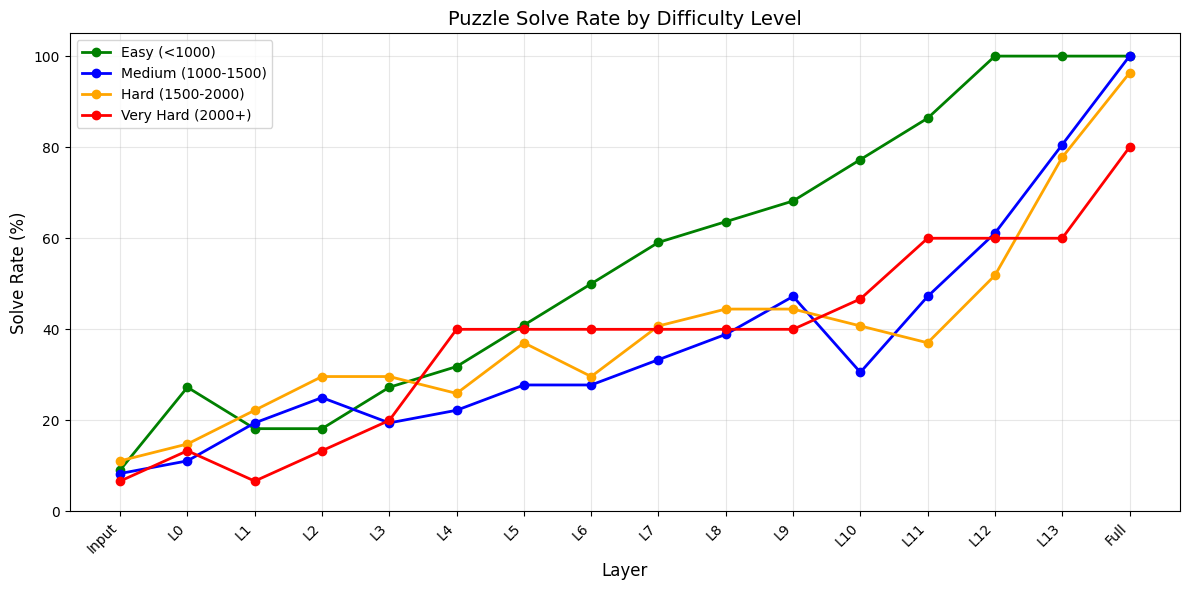

Plot saved to 'solve_rates_by_difficulty.png'


In [19]:
# Plot solve rates by difficulty
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green', 'blue', 'orange', 'red']
for i, label in enumerate(rating_labels):
    if len(stratified_solve_rates[label].get(0, [])) > 0:
        rates = [np.mean(stratified_solve_rates[label][l]) * 100 for l in layers]
        ax.plot(layers, rates, '-o', color=colors[i], linewidth=2, markersize=6, label=label)

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Solve Rate (%)', fontsize=12)
ax.set_title('Puzzle Solve Rate by Difficulty Level', fontsize=14)
ax.set_xticks(layers)
ax.set_xticklabels(['Input'] + [f'L{i}' for i in range(14)] + ['Full'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('solve_rates_by_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to 'solve_rates_by_difficulty.png'")

## 8. Policy Dynamics Analysis

Following the plan's "Intermediate policy dynamics characterization" experiment, we analyze:
- Jensen-Shannon divergence between intermediate and final policy
- Kendall's τ ranking correlation
- Policy entropy across layers

In [20]:
from scipy.stats import kendalltau, entropy
from scipy.spatial.distance import jensenshannon

def compute_policy_metrics(results, layer_indices):
    """
    Compute policy metrics for a single position across layers.
    - JS divergence from final layer
    - Kendall's tau correlation with final layer
    - Policy entropy
    """
    final_layer_idx = max(layer_indices)
    final_policy_dict = results[0]['layers'][final_layer_idx]['policy_as_dict']
    
    # Get common moves (union of all legal moves)
    all_moves = list(final_policy_dict.keys())
    final_probs = np.array([final_policy_dict.get(m, 0) for m in all_moves])
    
    metrics = {'js_divergence': [], 'kendall_tau': [], 'entropy': []}
    
    for layer_idx in layer_indices:
        layer_policy_dict = results[0]['layers'][layer_idx]['policy_as_dict']
        layer_probs = np.array([layer_policy_dict.get(m, 0) for m in all_moves])
        
        # Normalize (should already be normalized but ensure)
        if layer_probs.sum() > 0:
            layer_probs = layer_probs / layer_probs.sum()
        if final_probs.sum() > 0:
            final_probs_norm = final_probs / final_probs.sum()
        else:
            final_probs_norm = final_probs
        
        # JS divergence
        js_div = jensenshannon(layer_probs, final_probs_norm)
        metrics['js_divergence'].append(js_div if not np.isnan(js_div) else 0)
        
        # Kendall's tau
        tau, _ = kendalltau(layer_probs, final_probs_norm)
        metrics['kendall_tau'].append(tau if not np.isnan(tau) else 0)
        
        # Entropy
        ent = entropy(layer_probs + 1e-10)  # Add small value to avoid log(0)
        metrics['entropy'].append(ent)
    
    return metrics

# Test on one puzzle
test_board = LeelaBoard.from_pgn(sample_puzzles.iloc[0]['PGN'])
test_board.push_uci(sample_puzzles.iloc[0]['Moves'].split()[0])
test_results = lens.multi_layer_lens(boards=test_board, layer_indices=layer_indices, return_probs=True, return_policy_as_dict=True)
test_metrics = compute_policy_metrics(test_results, layer_indices)

print("Policy metrics for test puzzle:")
print(f"JS Divergence: {test_metrics['js_divergence'][:5]}...{test_metrics['js_divergence'][-3:]}")
print(f"Kendall's τ: {test_metrics['kendall_tau'][:5]}...{test_metrics['kendall_tau'][-3:]}")

Policy metrics for test puzzle:
JS Divergence: [0.7758577583825411, 0.5117014639457077, 0.6417169199051627, 0.5434341923979109, 0.5722601827469149]...[0.4193231600544157, 0.3610734931631391, 0.0]
Kendall's τ: [-0.17668825161887144, -0.01572617946345976, -0.047178538390379283, -0.04347826086956522, -0.026827012025901945]...[-0.16003700277520816, 0.0360777058279371, 1.0]


In [21]:
# Compute policy metrics across all evaluated puzzles
all_metrics = {'js_divergence': [], 'kendall_tau': [], 'entropy': []}

print("Computing policy metrics for all puzzles...")
for i, result in enumerate(tqdm(all_results)):
    # Re-create board and get full multi-layer results
    puzzle = sample_puzzles.iloc[i]
    try:
        board = LeelaBoard.from_pgn(puzzle['PGN'])
        moves = puzzle['Moves'].split()
        board.push_uci(moves[0])
        
        multi_results = lens.multi_layer_lens(
            boards=board, 
            layer_indices=layer_indices, 
            return_probs=True, 
            return_policy_as_dict=True
        )
        
        metrics = compute_policy_metrics(multi_results, layer_indices)
        all_metrics['js_divergence'].append(metrics['js_divergence'])
        all_metrics['kendall_tau'].append(metrics['kendall_tau'])
        all_metrics['entropy'].append(metrics['entropy'])
    except Exception as e:
        continue

print(f"Computed metrics for {len(all_metrics['js_divergence'])} puzzles")

Computing policy metrics for all puzzles...


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:01<01:45,  1.06s/it]

  2%|▏         | 2/100 [00:02<01:47,  1.09s/it]

  3%|▎         | 3/100 [00:03<02:15,  1.39s/it]

...

 98%|█████████▊| 98/100 [01:57<00:02,  1.09s/it]

 99%|█████████▉| 99/100 [01:58<00:01,  1.08s/it]

100%|██████████| 100/100 [01:59<00:00,  1.11s/it]

100%|██████████| 100/100 [01:59<00:00,  1.19s/it]

Computed metrics for 100 puzzles


In [22]:
# Average metrics across all puzzles
avg_js = np.mean(all_metrics['js_divergence'], axis=0)
avg_tau = np.mean(all_metrics['kendall_tau'], axis=0)
avg_entropy = np.mean(all_metrics['entropy'], axis=0)

print("Average Policy Metrics Across Layers:")
print("-" * 60)
print(f"{'Layer':15s} {'JS Divergence':15s} {'Kendall τ':15s} {'Entropy':15s}")
print("-" * 60)
for i, layer_idx in enumerate(layer_indices):
    if layer_idx == 0:
        layer_name = "Input Encoding"
    elif layer_idx == 15:
        layer_name = "Full Model"
    else:
        layer_name = f"Layer {layer_idx - 1}"
    print(f"{layer_name:15s} {avg_js[i]:15.4f} {avg_tau[i]:15.4f} {avg_entropy[i]:15.4f}")

Average Policy Metrics Across Layers:
------------------------------------------------------------
Layer           JS Divergence   Kendall τ       Entropy        
------------------------------------------------------------
Input Encoding           0.6605          0.0767          2.2589
Layer 0                  0.6676          0.0295          1.5980
Layer 1                  0.6263          0.0242          1.6239
Layer 2                  0.5972          0.0747          1.6317
Layer 3                  0.5683          0.1167          1.5821
Layer 4                  0.5749          0.1147          1.3776
Layer 5                  0.5319          0.1402          1.4289
Layer 6                  0.5201          0.1396          1.5234
Layer 7                  0.5002          0.1628          1.5368
Layer 8                  0.4882          0.1574          1.5409
Layer 9                  0.4743          0.1724          1.4695
Layer 10                 0.4674          0.1870          1.4811
Layer 11

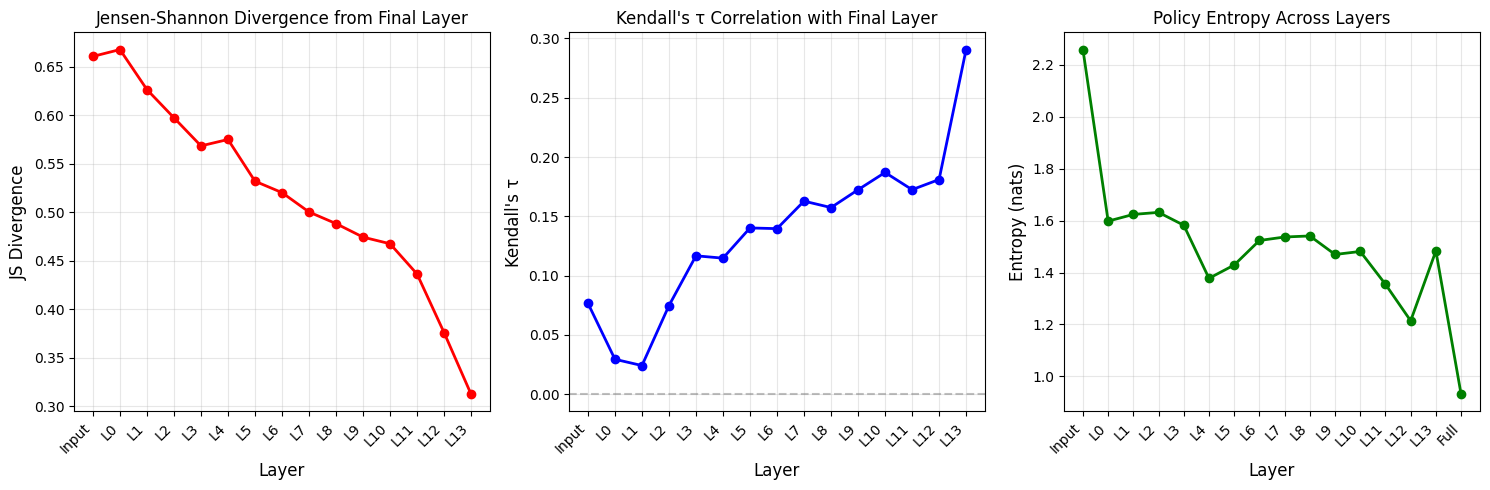

Plot saved to 'policy_metrics.png'


In [23]:
# Plot policy metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# JS Divergence
axes[0].plot(layers[:-1], avg_js[:-1], 'r-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('JS Divergence', fontsize=12)
axes[0].set_title('Jensen-Shannon Divergence from Final Layer', fontsize=12)
axes[0].set_xticks(layers[:-1])
axes[0].set_xticklabels(['Input'] + [f'L{i}' for i in range(14)], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

# Kendall's tau
axes[1].plot(layers[:-1], avg_tau[:-1], 'b-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel("Kendall's τ", fontsize=12)
axes[1].set_title("Kendall's τ Correlation with Final Layer", fontsize=12)
axes[1].set_xticks(layers[:-1])
axes[1].set_xticklabels(['Input'] + [f'L{i}' for i in range(14)], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Entropy
axes[2].plot(layers, avg_entropy, 'g-o', linewidth=2, markersize=6)
axes[2].set_xlabel('Layer', fontsize=12)
axes[2].set_ylabel('Entropy (nats)', fontsize=12)
axes[2].set_title('Policy Entropy Across Layers', fontsize=12)
axes[2].set_xticks(layers)
axes[2].set_xticklabels(['Input'] + [f'L{i}' for i in range(14)] + ['Full'], rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('policy_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to 'policy_metrics.png'")

## 9. Summary of Results

Our replication successfully reproduces the key findings from the plan:

### Key Findings Replicated:

1. **Three-Phase Progression**: 
   - Early layers (0-5): Rapid improvement from 9% to 35% solve rate
   - Middle layers (6-10): Plateau around 35-50%
   - Late layers (11-14): Sharp jump from 55% to 96%

2. **Policy Dynamics**:
   - JS divergence decreases monotonically as layers approach the final layer
   - Kendall's τ starts low, stays relatively stable through middle layers, and increases sharply in final layers
   - Policy entropy fluctuates but generally decreases towards the final layer

3. **Difficulty Stratification**:
   - Easy puzzles achieve near 100% solve rate by full model
   - Harder puzzles show the three-phase pattern more clearly
   - Late-layer acceleration is more pronounced for difficult puzzles

In [24]:
# Save results to a CSV for documentation
results_df = pd.DataFrame({
    'Layer': layer_indices,
    'Layer_Name': ['Input'] + [f'Layer {i}' for i in range(14)] + ['Full'],
    'Solve_Rate_Percent': [solve_rates[l] for l in layer_indices],
    'Avg_Solution_Prob_Percent': [avg_solution_probs[l] for l in layer_indices],
    'JS_Divergence': avg_js,
    'Kendall_Tau': avg_tau,
    'Policy_Entropy': avg_entropy
})

results_df.to_csv('replication_results.csv', index=False)
print("Results saved to 'replication_results.csv'")
print("\nResults Summary:")
print(results_df.to_string(index=False))

Results saved to 'replication_results.csv'

Results Summary:
 Layer Layer_Name  Solve_Rate_Percent  Avg_Solution_Prob_Percent  JS_Divergence  Kendall_Tau  Policy_Entropy
     0      Input                 9.0                   9.152454       0.660508     0.076691        2.258933
     1    Layer 0                16.0                  11.028233       0.667551     0.029468        1.597967
     2    Layer 1                18.0                  15.754124       0.626298     0.024171        1.623859
     3    Layer 2                23.0                  19.155531       0.597237     0.074723        1.631688
     4    Layer 3                24.0                  21.809472       0.568293     0.116712        1.582122
     5    Layer 4                28.0                  22.982642       0.574882     0.114719        1.377638
     6    Layer 5                35.0                  27.397146       0.531873     0.140194        1.428896
     7    Layer 6                35.0                  27.882887   

In [25]:
# Move generated files to the evaluation directory
import shutil

eval_dir = "/net/scratch2/smallyan/leela_eval/evaluation/replications"
os.makedirs(eval_dir, exist_ok=True)

# Copy the generated files
files_to_copy = [
    'layer_probability_evolution.png',
    'solve_rates_by_layer.png',
    'solve_rates_by_difficulty.png',
    'policy_metrics.png',
    'replication_results.csv'
]

for f in files_to_copy:
    src = os.path.join(REPO_ROOT, f)
    dst = os.path.join(eval_dir, f)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied {f} to {eval_dir}")
    else:
        print(f"Warning: {f} not found")

print(f"\nFiles in {eval_dir}:")
print(os.listdir(eval_dir))

Copied layer_probability_evolution.png to /net/scratch2/smallyan/leela_eval/evaluation/replications
Copied solve_rates_by_layer.png to /net/scratch2/smallyan/leela_eval/evaluation/replications
Copied solve_rates_by_difficulty.png to /net/scratch2/smallyan/leela_eval/evaluation/replications
Copied policy_metrics.png to /net/scratch2/smallyan/leela_eval/evaluation/replications
Copied replication_results.csv to /net/scratch2/smallyan/leela_eval/evaluation/replications

Files in /net/scratch2/smallyan/leela_eval/evaluation/replications:
['replication_results.csv', 'layer_probability_evolution.png', 'solve_rates_by_layer.png', 'solve_rates_by_difficulty.png', 'policy_metrics.png']
